# Simplified Python + Gradient Method Step-size Control

This notebook is written in a simple, human style.

We will do two things:

1. Learn the Python ideas needed for the exercise:
   - variables
   - data types
   - lists
   - functions
   - simple classes
   - NumPy arrays and matrices

2. Solve the uploaded nonlinear optimization exercise:
   - implement gradient descent
   - add step-size control
   - test it on the tridiagonal matrix problem
   - plot residuals
   - explain what happens when the dimension increases

The code is intentionally not written in a very compact or advanced way.  
It is written so that a beginner can read it line by line.

## Part 1 — Very small Python warm-up

Before solving the math problem, let us remember the Python basics.

Python works like a calculator, but it can also store values using names.

In [1]:
# A variable is just a name for a value

number_of_iterations = 10
tolerance = 1e-6
method_name = "Gradient descent"

print(number_of_iterations)
print(tolerance)
print(method_name)

10
1e-06
Gradient descent


## Data types

A **data type** tells Python what kind of object we are using.

Common examples:

- `int` means integer number
- `float` means decimal number
- `str` means text
- `bool` means True or False
- `list` means a collection of values

In [2]:
a = 5                 # integer
b = 2.5               # float
name = "Shakeel"      # string
is_converged = False  # boolean
residuals = [1.0, 0.4, 0.1]  # list

print(type(a))
print(type(b))
print(type(name))
print(type(is_converged))
print(type(residuals))

<class 'int'>
<class 'float'>
<class 'str'>
<class 'bool'>
<class 'list'>


## Lists

A list is useful when we want to store many values.

In gradient descent, we will store the residual after every iteration.

In [3]:
residual_list = []

residual_list.append(1.0)
residual_list.append(0.5)
residual_list.append(0.1)

print(residual_list)
print("First residual:", residual_list[0])
print("Last residual:", residual_list[-1])

[1.0, 0.5, 0.1]
First residual: 1.0
Last residual: 0.1


## For-loops

A loop repeats something.

This example prints the first 5 iteration numbers.

In [4]:
for k in range(5):
    print("Iteration number:", k)

Iteration number: 0
Iteration number: 1
Iteration number: 2
Iteration number: 3
Iteration number: 4


## If-statements

An if-statement makes a decision.

In gradient descent we stop when the residual becomes small enough.

In [5]:
residual = 0.000001
tolerance = 0.00001

if residual < tolerance:
    print("Stop. The residual is small enough.")
else:
    print("Continue. The residual is still too large.")

Stop. The residual is small enough.


## Functions

A function is useful when we do the same task again and again.

Mathematically, a function takes an input and gives an output.

Example:

\[
f(x) = x^2
\]

In [6]:
def square(x):
    return x * x

print(square(3))
print(square(5))

9
25


## NumPy

For optimization, we need vectors and matrices.

Python lists are okay for simple things, but for mathematics we normally use **NumPy**.

In [7]:
import numpy as np

x = np.array([1.0, 2.0, 3.0])

print("x =", x)
print("2*x =", 2*x)
print("x + x =", x + x)
print("dot product x·x =", x @ x)
print("Euclidean norm ||x|| =", np.linalg.norm(x))

x = [1. 2. 3.]
2*x = [2. 4. 6.]
x + x = [2. 4. 6.]
dot product x·x = 14.0
Euclidean norm ||x|| = 3.7416573867739413


## Matrix-vector multiplication

In the exercise, we work with a matrix \(Q\).

A matrix-vector product \(Qx\) is written in Python as:

```python
Q @ x
```

In [8]:
Q = np.array([
    [2.0, -1.0],
    [-1.0, 2.0]
])

x = np.array([1.0, 3.0])

print("Q =")
print(Q)

print("x =", x)

print("Qx =", Q @ x)

Q =
[[ 2. -1.]
 [-1.  2.]]
x = [1. 3.]
Qx = [-1.  5.]


## Eigenvalues

The exercise uses two important numbers:

\[
\mu = \text{smallest eigenvalue of } Q
\]

\[
L = \text{largest eigenvalue of } Q
\]

In Python we can compute them with `np.linalg.eigvalsh(Q)` when \(Q\) is symmetric.

In [9]:
eigenvalues = np.linalg.eigvalsh(Q)

mu = eigenvalues[0]
L = eigenvalues[-1]

print("Eigenvalues:", eigenvalues)
print("mu =", mu)
print("L =", L)

Eigenvalues: [1. 3.]
mu = 1.0
L = 3.0


# Part 2 — What is the optimization problem?

For the quadratic case we use this function:

\[
f(x) = \frac{1}{2}x^TQx - p^Tx + c
\]

Its gradient is:

\[
\nabla f(x) = Qx - p
\]

Gradient descent means:

\[
x_{k+1} = x_k - \alpha_k \nabla f(x_k)
\]

The important question is:

**How should we choose the step size \(\alpha_k\)?**

## Step-size rules from the exercise

We implement three step-size choices.

### Rule 1: Strongly convex step size

\[
\alpha = \frac{2}{L+\mu}
\]

This uses both the smallest and largest eigenvalues.

### Rule 2: Safe step size

\[
\alpha = \frac{1}{L}
\]

This only uses the largest eigenvalue.

### Rule 3: Complete relaxation for quadratic functions

\[
\alpha_k =
\frac{\|\nabla f(x_k)\|^2}
{\nabla f(x_k)^TQ\nabla f(x_k)}
\]

This changes the step size in every iteration.

## A simple class for functions

The exercise asks for methods like:

- `has_L()`
- `has_mu()`
- `has_Q()`

These methods just answer:

- Does this function know \(L\)?
- Does this function know \(\mu\)?
- Does this function know \(Q\)?

We will write this in a beginner-friendly way.

In [10]:
class SimpleFunction:
    """
    A small base class.

    This class is not doing the real mathematics.
    It only gives a common structure.
    """

    def value(self, x):
        raise NotImplementedError("Please define value(x) in the child class.")

    def grad(self, x):
        raise NotImplementedError("Please define grad(x) in the child class.")

    def has_L(self):
        return hasattr(self, "L")

    def has_mu(self):
        return hasattr(self, "mu")

    def has_Q(self):
        return hasattr(self, "Q")

## Quadratic function class

This represents:

\[
f(x)=\frac{1}{2}x^TQx-p^Tx+c
\]

and

\[
\nabla f(x)=Qx-p
\]

For this function:

- \(Q\) is known
- \(L\) is the largest eigenvalue of \(Q\)
- \(\mu\) is the smallest eigenvalue of \(Q\)

In [11]:
class QuadraticFunction(SimpleFunction):
    """
    Quadratic function:

        f(x) = 0.5*x^T*Q*x - p^T*x + c

    Gradient:

        grad f(x) = Q*x - p
    """

    def __init__(self, Q, p, c=0.0):
        self.Q = np.array(Q, dtype=float)
        self.p = np.array(p, dtype=float)
        self.c = float(c)

        eigenvalues = np.linalg.eigvalsh(self.Q)

        self.mu = float(eigenvalues[0])
        self.L = float(eigenvalues[-1])

        # We use this flag because the complete-relaxation formula is
        # used here only for pure quadratic functions.
        self.is_quadratic = True

    def value(self, x):
        x = np.array(x, dtype=float)
        return 0.5 * x @ (self.Q @ x) - self.p @ x + self.c

    def grad(self, x):
        x = np.array(x, dtype=float)
        return self.Q @ x - self.p

## Optional: classes similar to \(f_3\) and \(f_4\)

The PDF also mentions functions where:

\[
f_3(x)=\sqrt{1+x^TQx}
\]

Only \(L\) is available for this function.

And:

\[
f_4(x)=f_3(x)+\frac{1}{2}x^TQx
\]

For \(f_4\), we can use a lower and upper bound.

You do not need these classes for the tridiagonal matrix task, but they show the idea of `has_L`, `has_mu`, and `has_Q`.

In [12]:
class SqrtQuadraticFunction(SimpleFunction):
    """
    f3(x) = sqrt(1 + x^T Q x)

    Gradient:
        Qx / sqrt(1 + x^T Q x)
    """

    def __init__(self, Q):
        self.Q = np.array(Q, dtype=float)

        eigenvalues = np.linalg.eigvalsh(self.Q)
        self.L = float(eigenvalues[-1])

        self.is_quadratic = False

    def value(self, x):
        x = np.array(x, dtype=float)
        return np.sqrt(1.0 + x @ (self.Q @ x))

    def grad(self, x):
        x = np.array(x, dtype=float)
        denominator = np.sqrt(1.0 + x @ (self.Q @ x))
        return (self.Q @ x) / denominator


class SqrtPlusQuadraticFunction(SimpleFunction):
    """
    f4(x) = sqrt(1 + x^T Q x) + 0.5*x^T Q x
    """

    def __init__(self, Q):
        self.Q = np.array(Q, dtype=float)

        eigenvalues = np.linalg.eigvalsh(self.Q)

        # According to the exercise notes:
        # lower bound uses min eigenvalue
        # upper bound can be taken as 2*max eigenvalue
        self.mu = float(eigenvalues[0])
        self.L = float(2.0 * eigenvalues[-1])

        self.is_quadratic = False

    def value(self, x):
        x = np.array(x, dtype=float)
        part1 = np.sqrt(1.0 + x @ (self.Q @ x))
        part2 = 0.5 * x @ (self.Q @ x)
        return part1 + part2

    def grad(self, x):
        x = np.array(x, dtype=float)
        denominator = np.sqrt(1.0 + x @ (self.Q @ x))
        grad_part1 = (self.Q @ x) / denominator
        grad_part2 = self.Q @ x
        return grad_part1 + grad_part2

## Quick test of the function classes

Let us create a small \(2\times2\) example and check if the methods work.

In [13]:
Q_small = np.array([
    [2.0, -1.0],
    [-1.0, 2.0]
])

p_small = np.array([1.0, 1.0])

f2 = QuadraticFunction(Q_small, p_small)
f3 = SqrtQuadraticFunction(Q_small)
f4 = SqrtPlusQuadraticFunction(Q_small)

print("For f2:")
print("has_L:", f2.has_L())
print("has_mu:", f2.has_mu())
print("has_Q:", f2.has_Q())
print("L:", f2.L)
print("mu:", f2.mu)

print("\nFor f3:")
print("has_L:", f3.has_L())
print("has_mu:", f3.has_mu())
print("has_Q:", f3.has_Q())
print("L:", f3.L)

print("\nFor f4:")
print("has_L:", f4.has_L())
print("has_mu:", f4.has_mu())
print("has_Q:", f4.has_Q())
print("L:", f4.L)
print("mu:", f4.mu)

For f2:
has_L: True
has_mu: True
has_Q: True
L: 3.0
mu: 1.0

For f3:
has_L: True
has_mu: False
has_Q: True
L: 3.0

For f4:
has_L: True
has_mu: True
has_Q: True
L: 6.0
mu: 1.0


# Part 3 — Gradient descent with step-size control

Now we write the main algorithm.

The residual is:

\[
\text{residual} = \|\nabla f(x_k)\|
\]

If this number becomes small, then we are close to a stationary point.

For a convex quadratic problem, this is the minimum.

In [14]:
def choose_step_size(function, x, step_rule):
    """
    This function chooses alpha.

    step_rule can be:

    "strongly_convex" -> alpha = 2/(L + mu)
    "safe"            -> alpha = 1/L
    "relaxation"      -> alpha = ||grad||^2 / (grad^T Q grad)
    """

    gradient = function.grad(x)

    if step_rule == "strongly_convex":
        if not function.has_L() or not function.has_mu():
            raise ValueError("This step rule needs both L and mu.")

        alpha = 2.0 / (function.L + function.mu)
        return alpha

    if step_rule == "safe":
        if not function.has_L():
            raise ValueError("This step rule needs L.")

        alpha = 1.0 / function.L
        return alpha

    if step_rule == "relaxation":
        if not function.has_Q():
            raise ValueError("Complete relaxation needs Q.")

        if not getattr(function, "is_quadratic", False):
            raise ValueError("In this notebook, relaxation is used only for quadratic functions.")

        numerator = gradient @ gradient
        denominator = gradient @ (function.Q @ gradient)

        alpha = numerator / denominator
        return alpha

    raise ValueError("Unknown step rule.")

In [15]:
def gradient_descent(function, x0, step_rule, tol=1e-6, maxit=1000):
    """
    Simple gradient descent.

    Inputs:
        function  : object with grad(x)
        x0        : starting vector
        step_rule : how we choose alpha
        tol       : stopping tolerance
        maxit     : maximum number of iterations

    Outputs:
        x         : final vector
        residuals : list of residuals
        alphas    : list of step sizes
    """

    x = np.array(x0, dtype=float)

    residuals = []
    alphas = []

    first_residual = np.linalg.norm(function.grad(x))
    residuals.append(first_residual)

    k = 0

    while residuals[-1] > tol and k < maxit:

        alpha = choose_step_size(function, x, step_rule)

        gradient = function.grad(x)

        x = x - alpha * gradient

        new_residual = np.linalg.norm(function.grad(x))

        alphas.append(alpha)
        residuals.append(new_residual)

        k = k + 1

    return x, np.array(residuals), np.array(alphas)

## Small example before the main task

Let us minimize a small 2D quadratic function.

This is just to check that the algorithm works.

In [16]:
x0_small = np.array([0.0, 0.0])

for rule in ["safe", "strongly_convex", "relaxation"]:
    x_final, residuals, alphas = gradient_descent(
        function=f2,
        x0=x0_small,
        step_rule=rule,
        tol=1e-8,
        maxit=1000
    )

    print("Rule:", rule)
    print("Final x:", x_final)
    print("Final residual:", residuals[-1])
    print("Iterations:", len(residuals) - 1)
    print()

Rule: safe
Final x: [0.99999999 0.99999999]
Final residual: 7.485586308815911e-09
Iterations: 47

Rule: strongly_convex
Final x: [1. 1.]
Final residual: 5.268356063861754e-09
Iterations: 28

Rule: relaxation
Final x: [1. 1.]
Final residual: 0.0
Iterations: 1



# Part 4 — Tridiagonal matrix from the exercise

The exercise gives:

\[
Q=T_n=
\begin{pmatrix}
2 & -1 & 0 & \dots & 0\\
-1 & 2 & -1 & \dots & 0\\
0 & -1 & 2 & \dots & 0\\
\vdots & \vdots & \vdots & \ddots & -1\\
0 & 0 & 0 & -1 & 2
\end{pmatrix}
\]

and

\[
p = \mathbf{1}, \quad c=0, \quad x_0=0
\]

So we minimize:

\[
f(x)=\frac{1}{2}x^TQx-p^Tx
\]

In [17]:
def make_tridiagonal_matrix(n):
    """
    Create the tridiagonal matrix T_n.

    Main diagonal  :  2
    Upper diagonal : -1
    Lower diagonal : -1
    """

    Q = 2.0 * np.eye(n)

    for i in range(n - 1):
        Q[i, i + 1] = -1.0
        Q[i + 1, i] = -1.0

    return Q

In [18]:
# Small check

Q_5 = make_tridiagonal_matrix(5)

print(Q_5)

[[ 2. -1.  0.  0.  0.]
 [-1.  2. -1.  0.  0.]
 [ 0. -1.  2. -1.  0.]
 [ 0.  0. -1.  2. -1.]
 [ 0.  0.  0. -1.  2.]]


## Run the gradient method for one dimension

Let us start with \(n=20\).

We compare the three step-size choices.

In [19]:
import matplotlib.pyplot as plt

n = 20

Q = make_tridiagonal_matrix(n)
p = np.ones(n)
c = 0.0
x0 = np.zeros(n)

problem = QuadraticFunction(Q, p, c)

print("n =", n)
print("mu =", problem.mu)
print("L =", problem.L)
print("condition number L/mu =", problem.L / problem.mu)

Matplotlib is building the font cache; this may take a moment.


n = 20
mu = 0.02233834754974316
L = 3.9776616524502573
condition number L/mu = 178.0642746108582


In [20]:
results = {}

for rule in ["safe", "strongly_convex", "relaxation"]:
    x_final, residuals, alphas = gradient_descent(
        function=problem,
        x0=x0,
        step_rule=rule,
        tol=1e-6,
        maxit=10000
    )

    results[rule] = {
        "x_final": x_final,
        "residuals": residuals,
        "alphas": alphas,
        "iterations": len(residuals) - 1,
        "final_residual": residuals[-1]
    }

    print("Rule:", rule)
    print("Iterations:", len(residuals) - 1)
    print("Final residual:", residuals[-1])
    print()

Rule: safe
Iterations: 2705
Final residual: 9.969393732229447e-07

Rule: strongly_convex
Iterations: 1357
Final residual: 9.891073853868924e-07

Rule: relaxation
Iterations: 1342
Final residual: 9.84957112210622e-07



## Plot residuals

The PDF asks to plot the residual logarithmically over the iteration number.

We use `plt.semilogy(...)`, because the y-axis should be logarithmic.

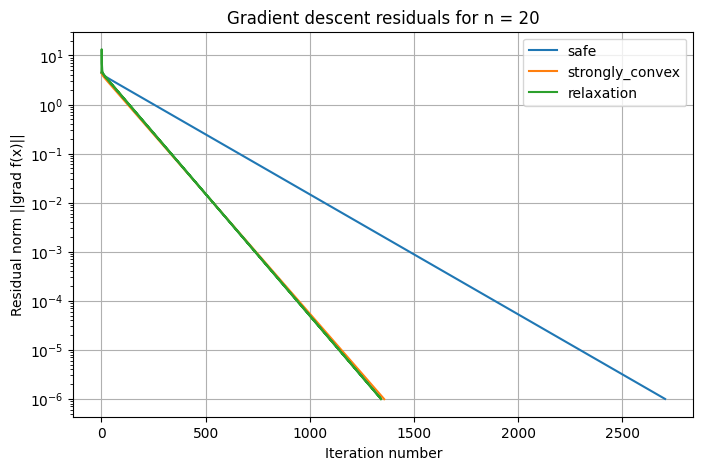

In [21]:
plt.figure(figsize=(8, 5))

for rule in results:
    residuals = results[rule]["residuals"]
    plt.semilogy(residuals, label=rule)

plt.xlabel("Iteration number")
plt.ylabel("Residual norm ||grad f(x)||")
plt.title("Gradient descent residuals for n = 20")
plt.grid(True)
plt.legend()
plt.show()

## What do we observe for \(n=20\)?

For this quadratic problem:

- `safe` uses \(\alpha=1/L\).  
  It is stable, but usually slower.

- `strongly_convex` uses \(\alpha=2/(L+\mu)\).  
  It uses more information and is faster here.

- `relaxation` computes a new step size every iteration.  
  It is often very good for quadratic functions.

Important intuition:

A step size that is too small moves safely, but slowly.  
A better step size moves more directly toward the solution.

# Part 5 — What happens when dimension \(n\) increases?

Now we repeat the experiment for several values of \(n\).

The tridiagonal matrix becomes harder when \(n\) becomes larger.

One reason is the condition number:

\[
\kappa = \frac{L}{\mu}
\]

When \(\kappa\) is large, gradient descent usually becomes slower.

In [22]:
dimension_results = []

for n in [10, 20, 50, 100]:

    Q = make_tridiagonal_matrix(n)
    p = np.ones(n)
    x0 = np.zeros(n)

    problem = QuadraticFunction(Q, p)

    for rule in ["safe", "strongly_convex", "relaxation"]:

        x_final, residuals, alphas = gradient_descent(
            function=problem,
            x0=x0,
            step_rule=rule,
            tol=1e-6,
            maxit=50000
        )

        dimension_results.append({
            "n": n,
            "rule": rule,
            "mu": problem.mu,
            "L": problem.L,
            "condition_number": problem.L / problem.mu,
            "iterations": len(residuals) - 1,
            "final_residual": residuals[-1],
            "converged": residuals[-1] <= 1e-6
        })

In [23]:
import pandas as pd

dimension_table = pd.DataFrame(dimension_results)

dimension_table

,n,rule,mu,L,condition_number,iterations,final_residual,converged
0,10,safe,0.081014,3.918986,48.374150,714,9.880461e-07,True
1,10,strongly_convex,0.081014,3.918986,48.374150,361,9.754717e-07,True
2,10,relaxation,0.081014,3.918986,48.374150,340,9.642255e-07,True
3,20,safe,0.022338,3.977662,178.064275,2705,9.969394e-07,True
4,20,strongly_convex,0.022338,3.977662,178.064275,1357,9.891074e-07,True
5,20,relaxation,0.022338,3.977662,178.064275,1342,9.849571e-07,True
6,50,safe,0.003793,3.996207,1053.478991,16507,9.996208e-07,True
7,50,strongly_convex,0.003793,3.996207,1053.478991,8258,9.985155e-07,True
8,50,relaxation,0.003793,3.996207,1053.478991,8364,9.986807e-07,True
9,100,safe,0.000967,3.999033,4133.642927,50000,5.043319e-05,False


## Plot iteration count versus dimension

This plot shows how many iterations were needed.

If a method did not reach the tolerance before `maxit`, it still shows `maxit`.

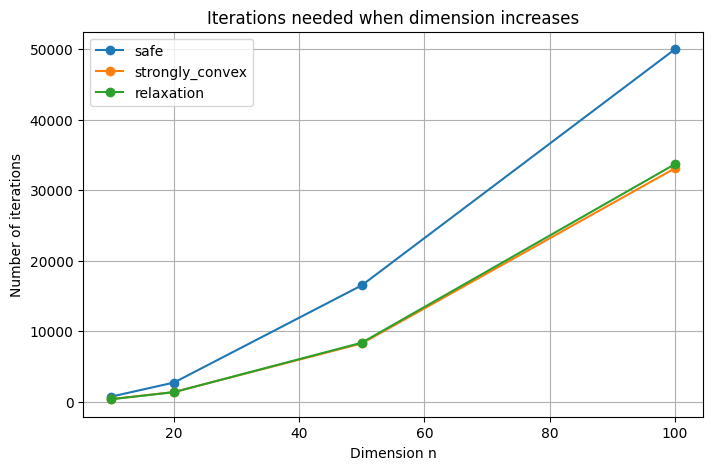

In [24]:
plt.figure(figsize=(8, 5))

for rule in ["safe", "strongly_convex", "relaxation"]:
    table_for_rule = dimension_table[dimension_table["rule"] == rule]
    plt.plot(
        table_for_rule["n"],
        table_for_rule["iterations"],
        marker="o",
        label=rule
    )

plt.xlabel("Dimension n")
plt.ylabel("Number of iterations")
plt.title("Iterations needed when dimension increases")
plt.grid(True)
plt.legend()
plt.show()

## Observation when \(n\) increases

When \(n\) increases:

- the smallest eigenvalue \(\mu\) becomes smaller
- \(L\) stays close to 4
- the condition number \(L/\mu\) becomes much larger
- gradient descent needs many more iterations

So the method becomes slower for larger \(n\).

This is not because the code is bad.  
It is because the optimization problem becomes more ill-conditioned.

# Part 6 — Final simple answer to the exercise

## Task 1 answer

We implemented gradient descent with step-size control:

\[
x_{k+1}=x_k-\alpha_k\nabla f(x_k)
\]

The three step-size rules are:

\[
\alpha=\frac{2}{L+\mu}
\]

\[
\alpha=\frac{1}{L}
\]

\[
\alpha_k=
\frac{\|\nabla f(x_k)\|^2}
{\nabla f(x_k)^TQ\nabla f(x_k)}
\]

We also added `has_L()`, `has_mu()`, and `has_Q()`.

## Task 2 answer

For the tridiagonal matrix \(T_n\):

- the residual decreases for all three methods
- `safe` is stable but slower
- `strongly_convex` is faster than `safe`
- `relaxation` is also very effective for this quadratic problem
- increasing \(n\) makes convergence slower because the condition number increases

# Small exercises for practice

Try these after you understand the notebook:

1. Change `n = 20` to `n = 10`, `50`, or `100`.
2. Change the tolerance from `1e-6` to `1e-8`.
3. Print the first 10 values of `alphas` for the relaxation method.
4. Replace `p = np.ones(n)` with `p = np.arange(1, n+1)`.
5. Try a different starting value, for example `x0 = 5*np.ones(n)`.

These small changes help you understand the algorithm better.